# Introduction

**Reza Sameni**  
Emory University

Repository organization, numerical conventions, and setup.

## Topics

- Navigate the package and the paired MATLAB functions.
- Recognize population fractions, counts, and time units.
- Check a minimal experiment before changing parameters.

**Run:** install the package with `python -m pip install -e ".[notebooks,dev]"`, then run all cells in order. All numerical functions are imported from `src/epidemic_modeling`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
import epidemic_modeling as em
from epidemic_modeling.plotting import configure_plots, repository_root, plot_compartments, plot_growth
root = repository_root()
configure_plots()
print(f"epidemic_modeling {em.__version__} · local data")

epidemic_modeling 2.0.0 · local data


## The modeling ladder

| Stage | Question | Library entry points |
| --- | --- | --- |
| Compartments | How do populations move between states? | `seirp`, `si_controlled` |
| Growth | Is incidence rising or falling? | `rt_exp_fit_*` |
| Estimation | What do noisy observations reveal about hidden states? | `generic_extended_kalman_filter`, `si_alpha_model_ekf` |
| Control | How do intervention costs trade against case burden? | `fit_npi_model`, `forecast_npi`, `optimal_npi` |

MATLAB and Python use **variables × time** matrices. Covariances are **variables × variables × time**. Python vectors are one-dimensional. SEIRP outputs include the initial condition; `si_alpha_controlled` outputs exclude it.

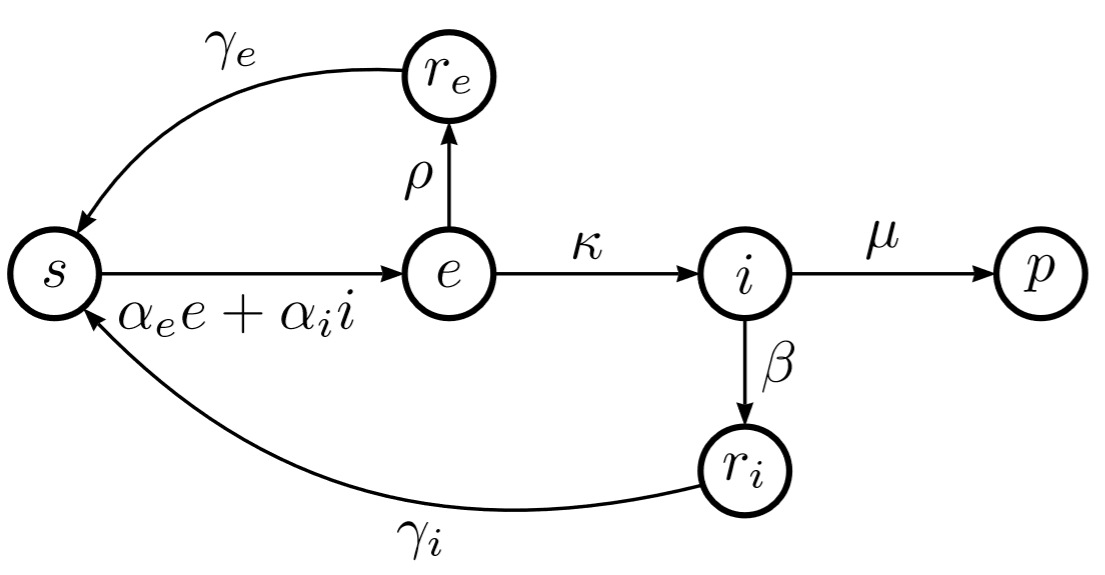

In [2]:
display(Image(filename=str(root/'figures/SEIRPModel.png'), width=680))

## First reproducible experiment

For the susceptible–infected model, transmission is $\alpha s i$ and removal is $\beta i$. We work in days and normalized population fractions. With $\alpha>\beta$, a small infected fraction initially grows.

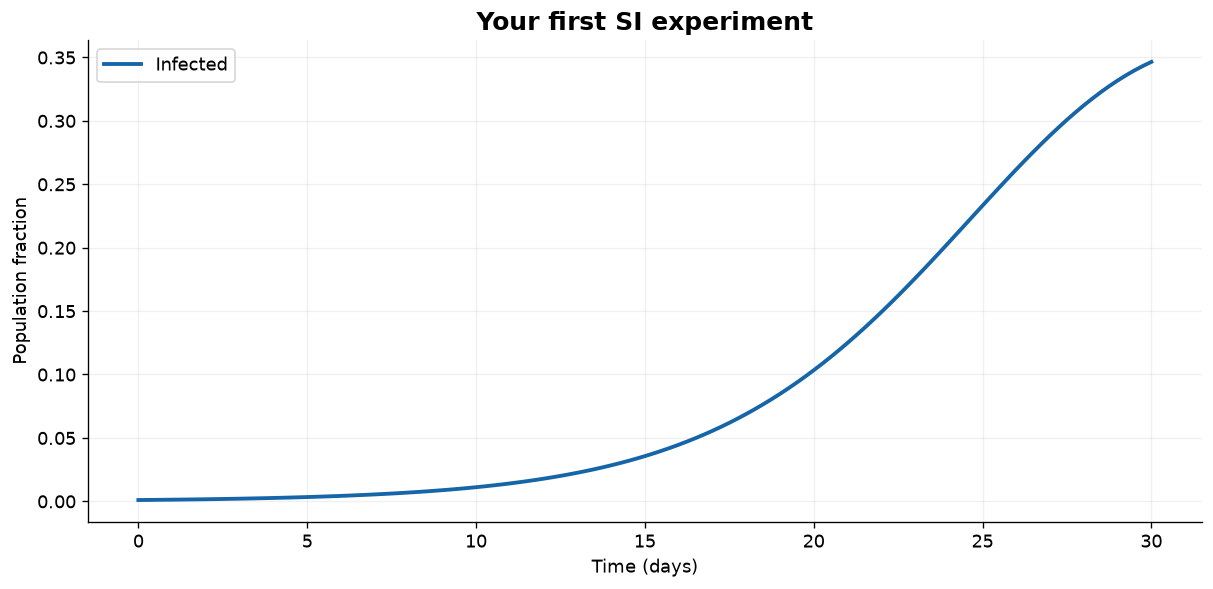

In [3]:
s, i = em.si_controlled(0.35, 0.1, 0.999, 0.001, 121, 0.25)
fig, ax = plt.subplots()
ax.plot(np.arange(len(i))*0.25, i, label='Infected')
ax.set(title='Your first SI experiment', xlabel='Time (days)', ylabel='Population fraction')
ax.legend(); plt.show()
assert len(s) == 121 and np.all((i >= 0) & (i <= 1))

## Running the examples

1. Open the compartment-model notebook and use **Restart Kernel and Run All Cells**.
2. Run `python -m pytest` from the repository root.
3. In MATLAB, run `setup_paths` and `runtests('matlab/tests')`.
4. Review the actual MATLAB/Python comparison instructions in the README.

**Discussion:** why do matching equations still require explicit indexing and random-noise conventions?

## References and next steps

1. Reza Sameni (2020). *Mathematical Modeling of Epidemic Diseases; A Case Study of the COVID-19 Coronavirus*. [arXiv:2003.11371](https://arxiv.org/abs/2003.11371).
2. Reza Sameni (2022). *Model-Based Prediction and Optimal Control of Pandemics by Non-Pharmaceutical Interventions*. IEEE JSTSP, **16**(2), 307–317. [DOI:10.1109/JSTSP.2021.3129118](https://doi.org/10.1109/JSTSP.2021.3129118).

Equations and existing research images originate from the cited work and the [original repository](https://github.com/alphanumericslab/EpidemicModeling). Consult `docs/api.md` for array shapes and `docs/migration.md` for deliberate fixes.